# 01 · Exploratory Data Analysis
**Swahili Audio Classification (Zindi)** · Owner: **Berissa**

Goal: understand the audio *as sequences* and turn every finding into a modelling decision.
Each section ends with a **Decision** box: after running, rewrite it in your own words using the
numbers you see. Those boxes go straight into the report's *Dataset and Exploratory Analysis* section.

## 0 · Setup
Run this cell first. On **Google Colab** it clones the repo, installs requirements and copies the
data from your Google Drive to the (much faster) local Colab disk. Locally it does nothing special.

**Before the first run:** put `Train.csv`, `Test.csv`, `SampleSubmission.csv` and `Audio.zip`
(downloaded from Zindi) in a Google Drive folder called `swahili_audio`, and set `REPO_URL`.

In [3]:
import os, sys, shutil, subprocess
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

    REPO_URL = "https://github.com/N-SilverJr/swahili-speech-recognition.git"
    REPO_DIR = Path("/content/swahili-speech-recognition")
    DRIVE_DATA = Path("/content/drive/MyDrive/swahili_audio")
    LOCAL_DATA = Path("/content/data")

    if not REPO_DIR.exists():
        subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)

    if not (LOCAL_DATA / ".ready").exists():
        LOCAL_DATA.mkdir(parents=True, exist_ok=True)

        # Copy the CSV files
        for f in DRIVE_DATA.glob("*.csv"):
            shutil.copy(f, LOCAL_DATA)

        # Copy the audio folder (instead of unzipping Audio.zip)
        audio_src = DRIVE_DATA / "swahili_words"
        audio_dst = LOCAL_DATA / "swahili_words"
        if audio_src.exists() and not audio_dst.exists():
            print("Copying audio files... this may take a few minutes")
            shutil.copytree(audio_src, audio_dst)

        (LOCAL_DATA / ".ready").touch()

    os.environ["DATA_DIR"] = str(LOCAL_DATA)
    os.environ["CACHE_DIR"] = str(DRIVE_DATA / "cache")
    os.environ["OUTPUT_BACKUP_DIR"] = str(DRIVE_DATA / "outputs")

else:
    if Path.cwd().name == "notebooks":
        os.chdir(Path.cwd().parent)

sys.path.insert(0, os.getcwd())
print("Working directory:", os.getcwd())
print("Data directory:", os.environ.get("DATA_DIR", "not set"))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory: /content/swahili-speech-recognition
Data directory: /content/data


In [8]:
from pathlib import Path
import shutil
import os

DRIVE_DATA = Path("/content/drive/MyDrive/swahili_audio")
LOCAL_DATA = Path("/content/data")

audio_src = DRIVE_DATA / "Swahili_words"
audio_dst = LOCAL_DATA / "swahili_words"

print("Source exists:", audio_src.exists())
print("Destination exists:", audio_dst.exists())

if audio_src.exists() and not audio_dst.exists():
    print("Copying audio files... this will take a few minutes. Please wait.")
    shutil.copytree(audio_src, audio_dst)
    print("Done copying!")
else:
    print("Nothing to copy (or source folder not found).")

Source exists: True
Destination exists: False
Copying audio files... this will take a few minutes. Please wait.
Done copying!


In [9]:
from pathlib import Path
import os

data_dir = Path(os.environ["DATA_DIR"])
print("Contents of /content/data:")
for item in sorted(data_dir.iterdir()):
    if item.is_dir():
        num_files = len(list(item.glob("*.wav")))
        print(f"  📁 {item.name}/  ({num_files} wav files)")
    else:
        print(f"  📄 {item.name}")

Contents of /content/data:
  📄 .ready
  📄 SampleSubmission.csv
  📄 Test.csv
  📄 Train.csv
  📁 swahili_words/  (6000 wav files)


In [7]:
from pathlib import Path

drive_data = Path("/content/drive/MyDrive/swahili_audio")

print("Contents of /content/drive/MyDrive/swahili_audio:")
print()

for item in sorted(drive_data.iterdir()):
    if item.is_dir():
        # Count files inside (just a sample to keep it fast)
        wavs = list(item.glob("**/*.wav"))
        print(f"  📁 {item.name}/   ← folder containing {len(wavs)} .wav files")
    else:
        print(f"  📄 {item.name}")

Contents of /content/drive/MyDrive/swahili_audio:

  📄 SampleSubmission.csv
  📁 Swahili_words/   ← folder containing 6000 .wav files
  📄 Test.csv
  📄 Train.csv


In [10]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

from src import config as C
from src.data import get_splits, load_unlabelled, add_paths
from src.features import compute_audio_stats, load_audio, logmel, compute_features
from src.utils import set_seed
from IPython.display import Audio, display

set_seed(C.SEED)
sns.set_theme(style="whitegrid")
EDA = C.RESULTS_DIR / "eda"
EDA.mkdir(parents=True, exist_ok=True)
summary = {}

## 1 · Load the data and create the shared split
Creates `data/splits.csv`: a stratified 80 / 10 / 10 train / validation / test split of `Train.csv`.
Zindi's `Test.csv` is unlabelled, so our **test** split is carved from the labelled data and is used
once per model at the very end. **Commit `data/splits.csv` to GitHub** so all members use the same split.

In [11]:
df = get_splits()                    # get_splits(rebuild=True) only if you deliberately want a new split
classes = sorted(df.label.unique())
zindi = add_paths(load_unlabelled())
summary.update(n_labelled=len(df), n_zindi_test=len(zindi), n_classes=len(classes), classes=classes,
               split_sizes=df.split.value_counts().to_dict())
print(json.dumps(summary, indent=1))
df.head()

Loaded 4200 labelled clips | audio column = 'Word_id' | labels from column 'Swahili_word' | 12 classes
Saved new split to /content/swahili-speech-recognition/data/splits.csv (commit this file!)
Indexed 6000 audio files under /content/data
Split sizes: {'train': 3359, 'val': 421, 'test': 420}
{
 "n_labelled": 4200,
 "n_zindi_test": 1800,
 "n_classes": 12,
 "classes": [
  "hapana",
  "kumi",
  "mbili",
  "moja",
  "nane",
  "ndio",
  "nne",
  "saba",
  "sita",
  "tano",
  "tatu",
  "tisa"
 ],
 "split_sizes": {
  "train": 3359,
  "val": 421,
  "test": 420
 }
}


,file,label,split,path
0,id_ore1uncoocjo.wav,mbili,train,/content/data/swahili_words/id_ore1uncoocjo.wav
1,id_6uh0lbu4im4c.wav,nane,train,/content/data/swahili_words/id_6uh0lbu4im4c.wav
2,id_399n3njaduqv.wav,moja,train,/content/data/swahili_words/id_399n3njaduqv.wav
3,id_pp2axmpwh7e0.wav,tisa,train,/content/data/swahili_words/id_pp2axmpwh7e0.wav
4,id_noyobejbarfw.wav,moja,train,/content/data/swahili_words/id_noyobejbarfw.wav


## 2 · Class distribution

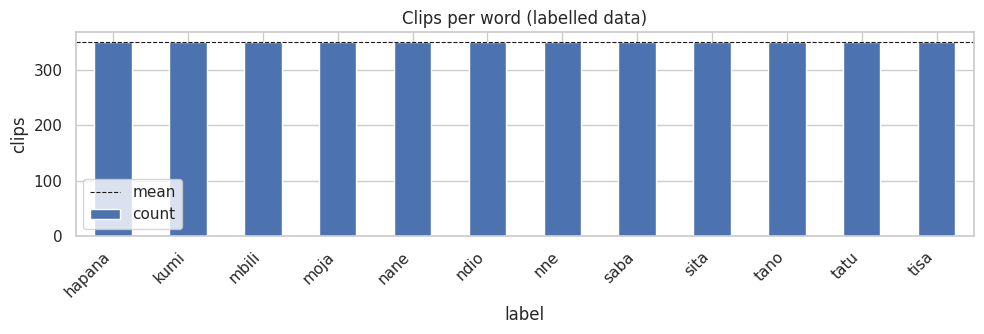

Imbalance ratio (largest / smallest class): 1.00


In [12]:
counts = df.label.value_counts().reindex(classes)
fig, ax = plt.subplots(figsize=(10, 3.5))
counts.plot.bar(ax=ax, color="C0")
ax.axhline(counts.mean(), ls="--", c="k", lw=.8, label="mean")
ax.set_title("Clips per word (labelled data)"); ax.set_ylabel("clips"); ax.legend()
plt.xticks(rotation=45, ha="right"); fig.tight_layout()
fig.savefig(C.FIG_DIR / "eda_class_distribution.png", dpi=150); plt.show()
summary["class_counts"] = counts.to_dict()
summary["imbalance_ratio_max_min"] = float(counts.max() / counts.min())
print(f"Imbalance ratio (largest / smallest class): {summary['imbalance_ratio_max_min']:.2f}")

> **Decision (edit after running):** If the ratio is close to 1 the classes are balanced, so accuracy
> and macro-F1 will tell a similar story and class weighting is unnecessary (tested anyway as an
> experiment). If it is well above ~1.5, report macro-F1 alongside accuracy and test class weights.

## 3 · Recording properties (sample rate, channels, format)
~300 different people recorded these on their own devices, so we expect heterogeneity.

In [13]:
stats_file = EDA / "audio_stats.csv"
if stats_file.exists():
    stats = pd.read_csv(stats_file)
else:
    all_paths = pd.concat([df.path, zindi.path]).drop_duplicates()
    stats = compute_audio_stats(all_paths)
    stats.to_csv(stats_file, index=False)
stats = stats.merge(df[["path", "label", "split", "file"]], on="path", how="left")
stats["label"] = stats["label"].fillna("(zindi test)")
lab = stats[stats.label != "(zindi test)"]

for col in ["orig_sr", "channels", "format"]:
    print(f"\n{col}:\n{stats[col].value_counts().to_string()}")
summary["orig_sample_rates"] = stats.orig_sr.value_counts().to_dict()
summary["channels"] = stats.channels.value_counts().to_dict()

audio stats:   0%|          | 0/6000 [00:00<?, ?it/s]


orig_sr:
orig_sr
16000    6000

channels:
channels
1    6000

format:
format
WAV    6000


> **Decision:** All audio is converted to **mono, 16 kHz**. 16 kHz keeps the speech band (<8 kHz),
> matches the rate wav2vec 2.0 / XLS-R were pre-trained on, and removes device differences in sample rate.

## 4 · Sequence length: duration and silence
The length of the sequence is the central modelling question: how many frames must a model see,
and how much of each clip is silence?

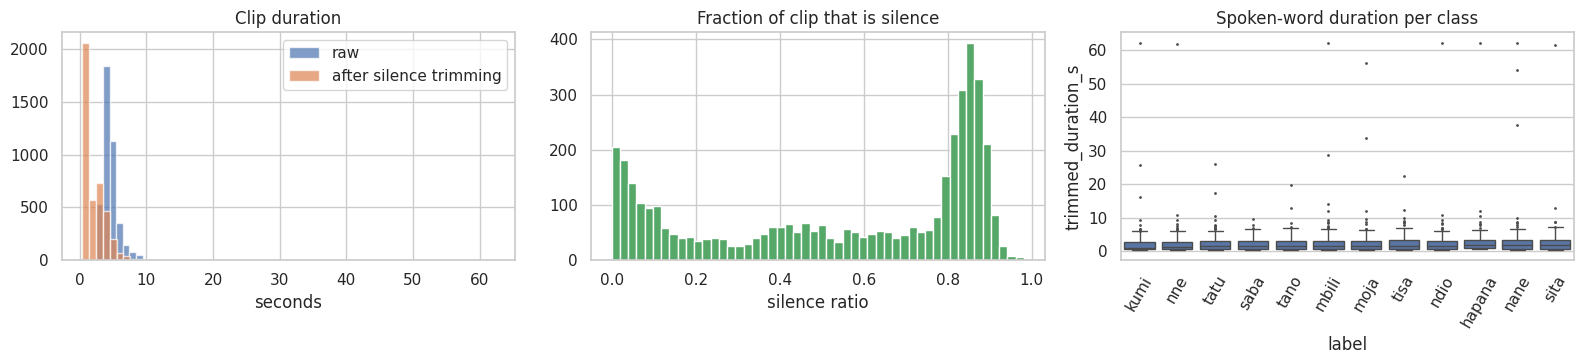

,count,mean,std,min,5%,50%,95%,99%,max
duration_s,4200.0,4.817,3.364,2.480,3.200,4.320,7.299,11.844,62.240
trimmed_duration_s,4200.0,2.250,3.391,0.384,0.512,1.472,5.248,8.672,62.208
lead_silence_s,4200.0,1.243,0.871,0.000,0.032,1.472,2.496,3.712,8.640
trail_silence_s,4200.0,1.323,1.446,0.000,0.000,1.400,2.849,4.928,39.168
silence_ratio,4200.0,0.547,0.324,0.000,0.020,0.656,0.892,0.920,0.982


99th percentile of trimmed duration = 8.67s  ->  suggested MAX_SECONDS = 8.7
Currently configured MAX_SECONDS = 1.5. 50.0% of clips would be cropped.
At a 10 ms hop that is 150 frames per clip and 24000 raw samples.


In [14]:
fig, ax = plt.subplots(1, 3, figsize=(16, 3.8))
ax[0].hist(lab.duration_s, bins=60, alpha=.7, label="raw")
ax[0].hist(lab.trimmed_duration_s, bins=60, alpha=.7, label="after silence trimming")
ax[0].set_xlabel("seconds"); ax[0].set_title("Clip duration"); ax[0].legend()
ax[1].hist(lab.silence_ratio, bins=50, color="C2"); ax[1].set_title("Fraction of clip that is silence")
ax[1].set_xlabel("silence ratio")
order = lab.groupby("label").trimmed_duration_s.median().sort_values().index
sns.boxplot(data=lab, x="label", y="trimmed_duration_s", order=order, ax=ax[2], fliersize=1)
ax[2].set_title("Spoken-word duration per class"); ax[2].tick_params(axis="x", rotation=60)
fig.tight_layout(); fig.savefig(C.FIG_DIR / "eda_durations.png", dpi=150); plt.show()

pct = lab[["duration_s", "trimmed_duration_s", "lead_silence_s", "trail_silence_s", "silence_ratio"]] \
    .describe(percentiles=[.05, .5, .95, .99]).T
display(pct.round(3))
p99 = float(lab.trimmed_duration_s.quantile(.99))
suggest = float(np.ceil(p99 * 10) / 10)
summary.update(duration_raw=pct.loc["duration_s"].to_dict(), duration_trimmed=pct.loc["trimmed_duration_s"].to_dict(),
               silence_ratio_median=float(lab.silence_ratio.median()), suggested_max_seconds=suggest)
print(f"99th percentile of trimmed duration = {p99:.2f}s  ->  suggested MAX_SECONDS = {suggest}")
print(f"Currently configured MAX_SECONDS = {C.MAX_SECONDS}. "
      f"{(lab.trimmed_duration_s > C.MAX_SECONDS).mean():.1%} of clips would be cropped.")
print(f"At a 10 ms hop that is {int(C.MAX_SECONDS * 100)} frames per clip "
      f"and {int(C.MAX_SECONDS * C.SR)} raw samples.")

> **Decision:** Leading/trailing silence is trimmed (`top_db=30`) because silence carries no
> information about the word but varies a lot between speakers. Clips are then centre-padded/cropped to
> `MAX_SECONDS` (≈ 99th percentile of spoken duration, so <1% of words are cut). **If the suggested
> value differs from the configured one, update `MAX_SECONDS` in `src/config.py` and say so in the log.**
> The resulting sequence length (~100–200 frames) is long for a vanilla RNN, one reason for gated
> units (GRU/LSTM) and attention pooling, and short enough for a 4-block CNN to cover the whole word.
> Duration differences between classes (right plot) are themselves informative: the order-free
> baseline gets duration as an explicit feature.

## 5 · Loudness, noise and clipping (recording quality)

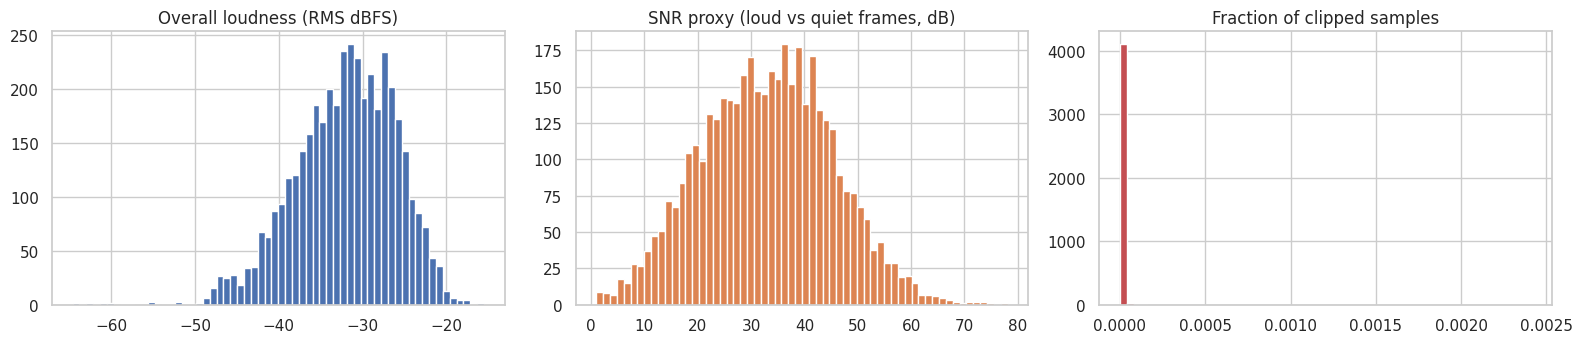

125 clips (3.0%) flagged as near-silent, very noisy or clipped -> results/eda/flagged_recordings.csv (revisited in error analysis)


In [15]:
fig, ax = plt.subplots(1, 3, figsize=(16, 3.6))
ax[0].hist(lab.rms_db, bins=60); ax[0].set_title("Overall loudness (RMS dBFS)")
ax[1].hist(lab.snr_est_db, bins=60, color="C1"); ax[1].set_title("SNR proxy (loud vs quiet frames, dB)")
ax[2].hist(lab.clip_frac.clip(upper=.02), bins=60, color="C3"); ax[2].set_title("Fraction of clipped samples")
fig.tight_layout(); fig.savefig(C.FIG_DIR / "eda_quality.png", dpi=150); plt.show()

flag = lab[(lab.trimmed_duration_s < 0.15) | (lab.rms_db < -50) | (lab.snr_est_db < 10) | (lab.clip_frac > 0.01)]
flag[["file", "label", "duration_s", "trimmed_duration_s", "rms_db", "snr_est_db", "clip_frac"]] \
    .to_csv(EDA / "flagged_recordings.csv", index=False)
summary.update(snr_median=float(lab.snr_est_db.median()), n_flagged=len(flag),
               frac_flagged=float(len(flag) / len(lab)))
print(f"{len(flag)} clips ({len(flag)/len(lab):.1%}) flagged as near-silent, very noisy or clipped "
      f"-> results/eda/flagged_recordings.csv (revisited in error analysis)")

> **Decision:** We do **not** delete flagged clips: the same problems will occur in real use (cheap
> phones, noisy environments), and removing them would make the evaluation optimistic. Instead we
> (i) peak-normalise every clip, (ii) use noise / masking augmentation, and (iii) check in error
> analysis whether errors concentrate in low-SNR clips. Listen to a few flagged clips below.

In [16]:
for _, r in flag.head(3).iterrows():
    print(r.file, r.label, f"SNR~{r.snr_est_db:.1f} dB, speech {r.trimmed_duration_s:.2f}s")
    display(Audio(r.path))

id_mg98epkgth3k.wav sita SNR~36.7 dB, speech 0.77s


id_qe3b7vcv1yw3.wav tisa SNR~8.4 dB, speech 9.92s


id_p9rscpr0fzrp.wav nne SNR~9.3 dB, speech 0.64s


## 6 · Duplicates and leakage check
Identical files in train and test would inflate scores.

In [17]:
dup = stats[stats.duplicated("md5", keep=False)].sort_values("md5")
cross = dup.groupby("md5").split.nunique()
conflict = dup[dup.label != "(zindi test)"].groupby("md5").label.nunique()
summary.update(n_duplicate_files=int(len(dup)), n_duplicate_groups_across_splits=int((cross > 1).sum()),
               n_duplicate_groups_conflicting_labels=int((conflict > 1).sum()))
print(f"{len(dup)} files share their exact bytes with another file; "
      f"{(cross > 1).sum()} duplicate groups span different splits; "
      f"{(conflict > 1).sum()} groups have conflicting labels.")

0 files share their exact bytes with another file; 0 duplicate groups span different splits; 0 groups have conflicting labels.


> **Decision:** If duplicates span splits, remove them from val/test (or re-split) and document it.
> A known limitation remains: Train.csv has **no speaker IDs**, so the same person can appear in both
> train and test. Our test scores therefore measure performance on *seen* speakers and are likely
> optimistic for new speakers (discussed in Limitations).

## 7 · What the words look like (log-mel spectrograms)
One random example per word. Time runs left to right: this is the sequence the models must read.

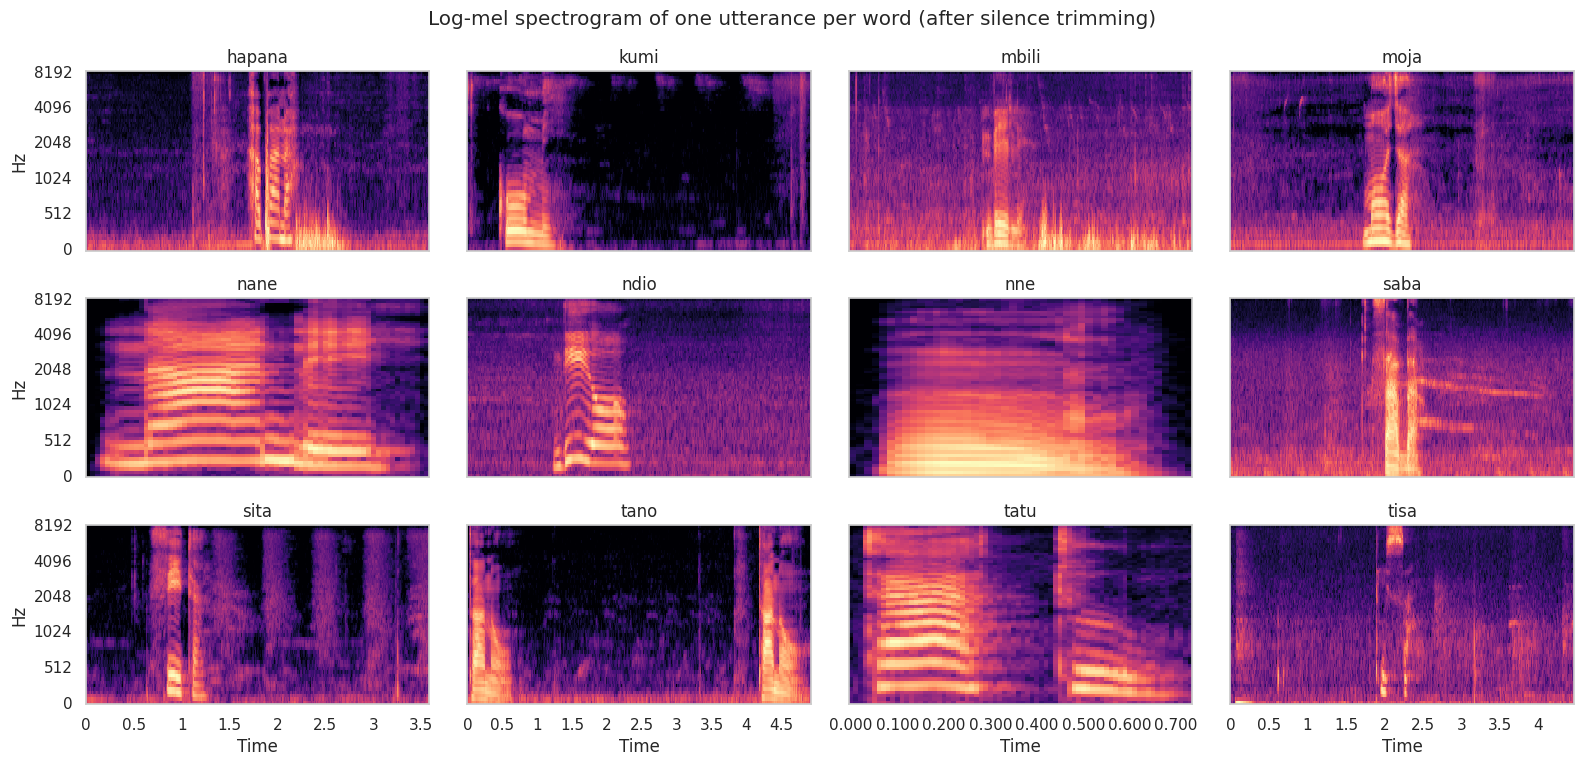

In [18]:
rng = np.random.default_rng(C.SEED)
ncol = 4
nrow = int(np.ceil(len(classes) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4 * ncol, 2.6 * nrow))
for ax, c in zip(axes.ravel(), classes):
    p = rng.choice(df[df.label == c].path.values)
    S = logmel(load_audio(p))
    librosa.display.specshow(S, sr=C.SR, hop_length=C.HOP_LENGTH, x_axis="time", y_axis="mel",
                             fmax=C.FMAX, ax=ax, cmap="magma")
    ax.set_title(c); ax.label_outer()
for ax in axes.ravel()[len(classes):]:
    ax.axis("off")
fig.suptitle("Log-mel spectrogram of one utterance per word (after silence trimming)")
fig.tight_layout(); fig.savefig(C.FIG_DIR / "eda_spectrograms_per_word.png", dpi=150); plt.show()

### Within-class variability: the same word from four different speakers

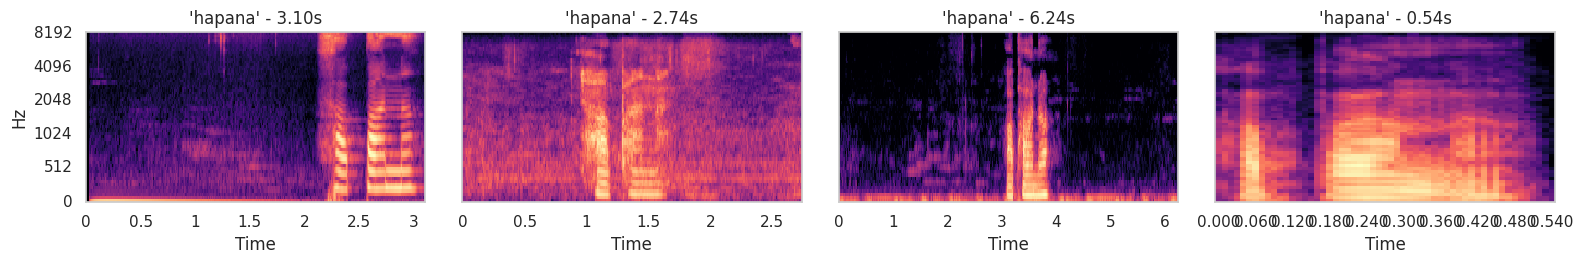

In [19]:
c = classes[0]
fig, axes = plt.subplots(1, 4, figsize=(16, 2.8))
for ax, p in zip(axes, rng.choice(df[df.label == c].path.values, 4, replace=False)):
    y = load_audio(p)
    librosa.display.specshow(logmel(y), sr=C.SR, hop_length=C.HOP_LENGTH, x_axis="time", y_axis="mel",
                             fmax=C.FMAX, ax=ax, cmap="magma")
    ax.set_title(f"'{c}' - {len(y)/C.SR:.2f}s"); ax.label_outer()
fig.tight_layout(); fig.savefig(C.FIG_DIR / "eda_within_class_variability.png", dpi=150); plt.show()

> **Decision:** The same word differs in speed (length), pitch and loudness across speakers, and its
> position in the clip shifts. This motivates: time-shift and SpecAugment augmentation;
> translation-invariant convolutions; alignment-tolerant models (DTW, RNN); and pretrained
> representations that are robust to speaker variation (wav2vec 2.0).

## 8 · Which words are acoustically similar? (predicting confusions before modelling)
Cosine similarity between class-average *order-free* MFCC summaries. High similarity = the words
contain similar sounds; if they differ mainly in the *order* of those sounds, an order-free model
will confuse them, while sequential models should not.

stats features:   0%|          | 0/3359 [00:00<?, ?it/s]

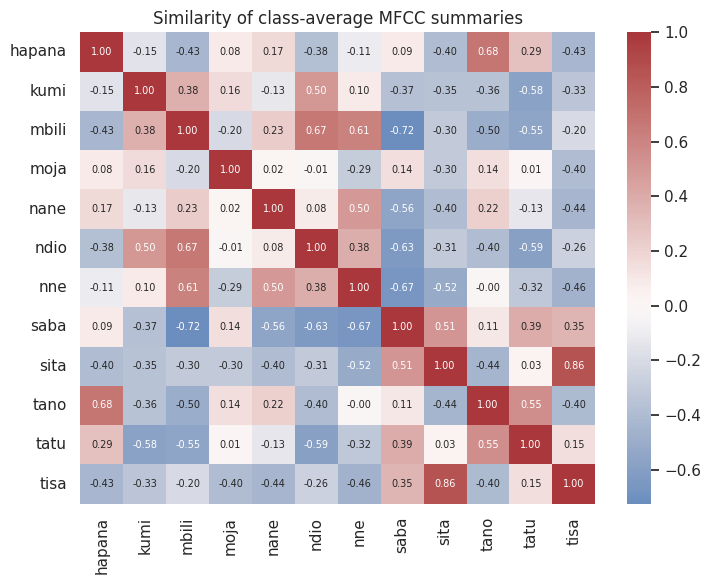

Most similar word pairs (expected confusions):
 sita    tisa    0.865
hapana  tano    0.678
mbili   ndio    0.668
        nne     0.612
tano    tatu    0.552


In [20]:
tr = df[df.split == "train"]
Xs = compute_features(tr.path, "stats")
Z = StandardScaler().fit_transform(Xs)
cent = np.stack([Z[tr.label.values == c].mean(0) for c in classes])
cent /= np.linalg.norm(cent, axis=1, keepdims=True)
sim = pd.DataFrame(cent @ cent.T, index=classes, columns=classes)
fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(sim, cmap="vlag", center=0, annot=True, fmt=".2f", annot_kws={"size": 7}, ax=ax)
ax.set_title("Similarity of class-average MFCC summaries"); fig.tight_layout()
fig.savefig(C.FIG_DIR / "eda_class_similarity.png", dpi=150); plt.show()
pairs = sim.where(np.triu(np.ones(sim.shape, bool), 1)).stack().sort_values(ascending=False)
summary["most_similar_pairs"] = {f"{a} / {b}": round(float(v), 3) for (a, b), v in pairs.head(5).items()}
print("Most similar word pairs (expected confusions):\n", pairs.head(5).round(3).to_string())

## 9 · t-SNE of order-free features
If words overlap here, information is missing from a bag-of-frames summary, i.e. the temporal
structure matters. Compare later with how well the sequential models separate the same words.

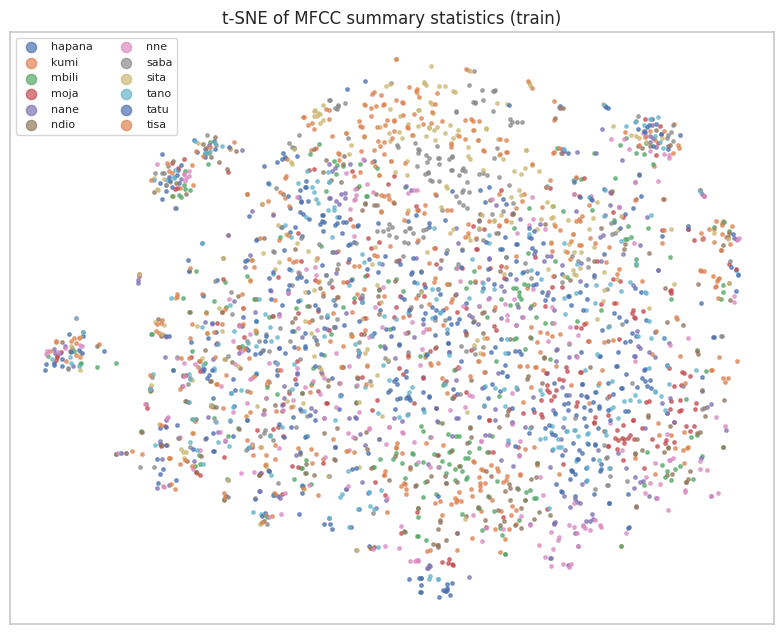

In [21]:
n = min(3000, len(Z))
idx = rng.choice(len(Z), n, replace=False)
emb = TSNE(n_components=2, perplexity=30, random_state=C.SEED, init="pca").fit_transform(Z[idx])
fig, ax = plt.subplots(figsize=(8, 6.5))
for c in classes:
    m = tr.label.values[idx] == c
    ax.scatter(emb[m, 0], emb[m, 1], s=6, label=c, alpha=.7)
ax.legend(markerscale=3, fontsize=8, ncol=2); ax.set_title("t-SNE of MFCC summary statistics (train)")
ax.set_xticks([]); ax.set_yticks([]); fig.tight_layout()
fig.savefig(C.FIG_DIR / "eda_tsne.png", dpi=150); plt.show()

## 10 · Save the summary for the report

In [22]:
(EDA / "eda_summary.json").write_text(json.dumps(summary, indent=2, default=str))
print(json.dumps(summary, indent=2, default=str)[:3000])

{
  "n_labelled": 4200,
  "n_zindi_test": 1800,
  "n_classes": 12,
  "classes": [
    "hapana",
    "kumi",
    "mbili",
    "moja",
    "nane",
    "ndio",
    "nne",
    "saba",
    "sita",
    "tano",
    "tatu",
    "tisa"
  ],
  "split_sizes": {
    "train": 3359,
    "val": 421,
    "test": 420
  },
  "class_counts": {
    "hapana": 350,
    "kumi": 350,
    "mbili": 350,
    "moja": 350,
    "nane": 350,
    "ndio": 350,
    "nne": 350,
    "saba": 350,
    "sita": 350,
    "tano": 350,
    "tatu": 350,
    "tisa": 350
  },
  "imbalance_ratio_max_min": 1.0,
  "orig_sample_rates": {
    "16000": 6000
  },
  "channels": {
    "1": 6000
  },
  "duration_raw": {
    "count": 4200.0,
    "mean": 4.816552380952381,
    "std": 3.3635424684759334,
    "min": 2.48,
    "5%": 3.2,
    "50%": 4.32,
    "95%": 7.299199999999983,
    "99%": 11.844000000000086,
    "max": 62.24
  },
  "duration_trimmed": {
    "count": 4200.0,
    "mean": 2.250167619047619,
    "std": 3.391276038924419,
    "

In [23]:
from src.utils import persist_outputs
persist_outputs()

Outputs copied to /content/drive/MyDrive/swahili_audio/outputs
